In [40]:
#PACKAGES

#Load Key
import os
from dotenv import load_dotenv

load_dotenv()

assert os.getenv("GEMINI_API_KEY"), "API key not found"
print("API key loaded successfully")

#Initialize Gemini
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    temperature=0,
    google_api_key=os.getenv("GEMINI_API_KEY")
)

response = llm.invoke("Say hello")
print(response.content)

#LangGraph
from langchain_core.tools import tool
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import SystemMessage
from IPython.display import Image, display
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver

API key loaded successfully
Hello there! How can I help you today?


In [41]:
#TOOL 1: DRUG LOOKUP

@tool
def drug_lookup(drug_name: str) -> str:
    """Look up clinical information about a medication.
    Use this when the user asks about a specific drug, its uses,
    side effects, or drug class.
    
    Args:
        drug_name: The name of the drug to look up (brand or generic name)
    """

    drugs = {
        "warfarin": {
            "generic_name": "Warfarin",
            "brand_names": ["Coumadin", "Jantoven"],
            "drug_class": "Vitamin K antagonist (Anticoagulant)",
            "common_uses": ["Blood clot prevention", "Atrial fibrillation", "Deep vein thrombosis"],
            "side_effects": ["Bleeding", "Bruising", "Nausea"],
            "atc_code": "B01AA03"
        },
        "aspirin": {
            "generic_name": "Acetylsalicylic acid",
            "brand_names": ["Bayer", "Aspirin"],
            "drug_class": "Platelet aggregation inhibitor (NSAID)",
            "common_uses": ["Pain relief", "Fever reduction", "Heart attack prevention"],
            "side_effects": ["Stomach irritation", "Bleeding", "Tinnitus"],
            "atc_code": "B01AC06"
        },
        "metformin": {
            "generic_name": "Metformin",
            "brand_names": ["Glucophage", "Fortamet"],
            "drug_class": "Biguanide (Oral antidiabetic)",
            "common_uses": ["Type 2 diabetes", "Insulin resistance", "PCOS"],
            "side_effects": ["Nausea", "Diarrhea", "Lactic acidosis (rare)"],
            "atc_code": "A10BA02"
        },
        "lisinopril": {
            "generic_name": "Lisinopril",
            "brand_names": ["Prinivil", "Zestril"],
            "drug_class": "ACE inhibitor (Antihypertensive)",
            "common_uses": ["Hypertension", "Heart failure", "Post-MI protection"],
            "side_effects": ["Dry cough", "Dizziness", "Hyperkalemia"],
            "atc_code": "C09AA03"
        },
        "insulin": {
            "generic_name": "Insulin (various types)",
            "brand_names": ["Lantus", "Humalog", "Novolog", "Tresiba"],
            "drug_class": "Insulin and analogues",
            "common_uses": ["Type 1 diabetes", "Type 2 diabetes", "Diabetic ketoacidosis"],
            "side_effects": ["Hypoglycemia", "Weight gain", "Injection site reactions"],
            "atc_code": "A10A"
        }
    }
    
    drug_key = drug_name.lower().strip()
    
    #Search by generic name or brand name
    for key, info in drugs.items():
        if drug_key == key or drug_key in [b.lower() for b in info["brand_names"]]:
            return (
                f"Drug: {info['generic_name']}\n"
                f"Brand Names: {', '.join(info['brand_names'])}\n"
                f"Drug Class: {info['drug_class']}\n"
                f"Common Uses: {', '.join(info['common_uses'])}\n"
                f"Side Effects: {', '.join(info['side_effects'])}\n"
                f"ATC Code: {info['atc_code']}"
            )
    
    #Not found
    return f"Drug '{drug_name}' not found. Available: {', '.join(drugs.keys())}"

In [42]:
#TOOL 2: SYMPTOM CHECKER

@tool
def symptom_checker(symptoms: str) -> str:
    """Check possible conditions based on reported symptoms.
    Use this when the user describes symptoms and wants to know
    possible conditions or diagnoses.
    
    Args:
        symptoms: Comma-separated list of symptoms (e.g., 'chest pain, shortness of breath')
    """
    
    condition_map = {
        "chest pain": [
            {"condition": "Myocardial Infarction (MI)", "icd10": "I21", "urgency": "Emergency"},
            {"condition": "Angina Pectoris", "icd10": "I20", "urgency": "Urgent"},
            {"condition": "GERD", "icd10": "K21", "urgency": "Non-urgent"}
        ],
        "shortness of breath": [
            {"condition": "Asthma", "icd10": "J45", "urgency": "Urgent"},
            {"condition": "Heart Failure", "icd10": "I50", "urgency": "Emergency"},
            {"condition": "COPD", "icd10": "J44", "urgency": "Urgent"}
        ],
        "frequent urination": [
            {"condition": "Type 2 Diabetes Mellitus", "icd10": "E11", "urgency": "Non-urgent"},
            {"condition": "Urinary Tract Infection", "icd10": "N39.0", "urgency": "Urgent"}
        ],
        "blurred vision": [
            {"condition": "Diabetic Retinopathy", "icd10": "E11.3", "urgency": "Urgent"},
            {"condition": "Glaucoma", "icd10": "H40", "urgency": "Urgent"},
            {"condition": "Cataracts", "icd10": "H25", "urgency": "Non-urgent"}
        ],
        "fatigue": [
            {"condition": "Anemia", "icd10": "D64.9", "urgency": "Non-urgent"},
            {"condition": "Hypothyroidism", "icd10": "E03", "urgency": "Non-urgent"},
            {"condition": "Depression", "icd10": "F32", "urgency": "Non-urgent"}
        ],
        "headache": [
            {"condition": "Tension Headache", "icd10": "G44.2", "urgency": "Non-urgent"},
            {"condition": "Migraine", "icd10": "G43", "urgency": "Non-urgent"},
            {"condition": "Hypertension", "icd10": "I10", "urgency": "Urgent"}
        ]
    }
    
    symptom_list = [s.strip().lower() for s in symptoms.split(",")]
    
    results = []
    matched = set()  

    #Search for symptom
    for symptom in symptom_list:
        if symptom in condition_map:
            for c in condition_map[symptom]:
                if c["condition"] not in matched:
                    matched.add(c["condition"])
                    results.append(f"- {c['condition']} (ICD-10: {c['icd10']}) [{c['urgency']}]")
    
    if not results:
        available = ", ".join(condition_map.keys())
        return f"No conditions found for: {symptoms}. Try: {available}"

    #Not found
    return f"Possible conditions for ({symptoms}):\n" + "\n".join(results)

In [43]:
#TOOL 3: MEDICAL TERM TRANSLATOR

@tool
def medical_term_translator(term: str) -> str:
    """Translate colloquial or abbreviated medical terms to clinical terminology.
    Use this when the user uses informal language, abbreviations, or brand names.
    
    Args:
        term: The colloquial or abbreviated medical term to translate
    """
    
    translations = {
        #Colloquial → clinical
        "blood thinners": {"clinical": "Anticoagulants", "examples": ["Warfarin", "Heparin", "Rivaroxaban"]},
        "heart attack": {"clinical": "Myocardial Infarction (MI)", "examples": ["Acute MI", "STEMI", "NSTEMI"]},
        "sugar disease": {"clinical": "Diabetes Mellitus", "examples": ["Type 1 DM", "Type 2 DM"]},
        "high blood pressure": {"clinical": "Hypertension", "examples": ["Essential hypertension", "Secondary hypertension"]},
        "water pill": {"clinical": "Diuretic", "examples": ["Furosemide", "Hydrochlorothiazide"]},
        #Abbreviations → clinical
        "dm": {"clinical": "Diabetes Mellitus", "examples": ["Type 1 DM", "Type 2 DM"]},
        "mi": {"clinical": "Myocardial Infarction", "examples": ["Acute MI", "STEMI", "NSTEMI"]},
        "bp": {"clinical": "Blood Pressure", "examples": ["Systolic BP", "Diastolic BP"]},
        "copd": {"clinical": "Chronic Obstructive Pulmonary Disease", "examples": ["Emphysema", "Chronic bronchitis"]},
        #Brand names → generic
        "tylenol": {"clinical": "Acetaminophen (Paracetamol)", "examples": ["Tylenol", "Panadol"]},
        "coumadin": {"clinical": "Warfarin", "examples": ["Coumadin", "Jantoven"]}
    }
    
    term_key = term.lower().strip()
    
    #Look up the term
    if term_key in translations:
        info = translations[term_key]
        return (
            f"'{term}' → {info['clinical']}\n"
            f"Examples: {', '.join(info['examples'])}"
        )

    #Not found
    return f"Term '{term}' not found. It may already be a clinical term."

In [44]:
#BIND TOOLS TO THE LLM

#Bind
tools = [drug_lookup, symptom_checker, medical_term_translator]
llm_with_tools = llm.bind_tools(tools)

#Test
response = llm_with_tools.invoke("What can you tell me about warfarin?")
print("Content:", response.content)
print("Tool calls:", response.tool_calls)

Content: 
Tool calls: [{'name': 'drug_lookup', 'args': {'drug_name': 'warfarin'}, 'id': '3174a376-30d3-4107-a558-585a23dad0b2', 'type': 'tool_call'}]


In [45]:
#DEFINE STATE AND BUILD THE GRAPH

#State the conversation history that flows through the graph
class State(TypedDict):
    messages: Annotated[list, add_messages]

#Prompt
SYSTEM_PROMPT = """You are a medical assistant helping healthcare researchers.
You have access to three tools:
1. drug_lookup - Find information about specific medications
2. symptom_checker - Check possible conditions based on symptoms
3. medical_term_translator - Translate informal terms to clinical terminology

Always use the appropriate tool before answering. If a user uses informal
medical language, translate it first, then look up the relevant information.
Be concise and clinical in your responses."""

#Node 1: Chatbot (Calls the LLM with conversation history)
def chatbot(state: State):
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    
    return {"messages": [response]}

#Node 2: Tool executor (Runs whatever tool the LLM requested)
tool_node = ToolNode(tools=tools)

#Conditional edge (Did the LLM request a tool call or give a final answer?)
def should_continue(state: State):
    last_message = state["messages"][-1]
    
    if last_message.tool_calls:
        return "tools"     
        
    return END            

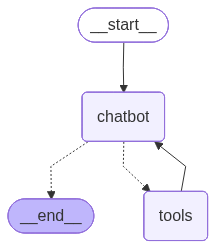

In [46]:
#COMPILE AND VISUALIZE THE GRAPH

#Build the graph: START → chatbot → tools → chatbot → ... → END
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", tool_node)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges(
    "chatbot",
    should_continue,
    {"tools": "tools", END: END}
)
graph_builder.add_edge("tools", "chatbot")

#Compile
graph = graph_builder.compile()

#Visualize
display(Image(graph.get_graph().draw_mermaid_png()))

In [47]:
#RUN AGENT

def run_agent(question: str):
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print(f"{'='*60}")
    
    events = graph.stream(
        {"messages": [HumanMessage(content=question)]},
        stream_mode="values"
    )
    
    for event in events:
        last_msg = event["messages"][-1]
        
        #LLM decided to call a tool
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            for tc in last_msg.tool_calls:
                print(f"\n🔧 Tool Call: {tc['name']}({tc['args']})")
        
        #Tool returned a result
        elif last_msg.type == "tool":
            print(f"\n📋 Tool Result:\n{last_msg.content[:300]}")
        
        #LLM gave a final answer
        elif last_msg.type == "ai" and last_msg.content:
            print(f"\n🤖 Agent Response:\n{last_msg.content}")

In [48]:
#TESTS

run_agent("What is metformin used for?")
run_agent("My patient has chest pain and shortness of breath. What could it be?")
run_agent("What are blood thinners and which ones are most common?")
run_agent("What medications are used to treat DM?")
run_agent("A patient with high blood pressure is asking about water pills. Can you explain?")


Question: What is metformin used for?

🔧 Tool Call: drug_lookup({'drug_name': 'metformin'})

📋 Tool Result:
Drug: Metformin
Brand Names: Glucophage, Fortamet
Drug Class: Biguanide (Oral antidiabetic)
Common Uses: Type 2 diabetes, Insulin resistance, PCOS
Side Effects: Nausea, Diarrhea, Lactic acidosis (rare)
ATC Code: A10BA02

🤖 Agent Response:
Metformin is an oral antidiabetic drug in the biguanide class. It is commonly used to treat type 2 diabetes, insulin resistance, and polycystic ovary syndrome (PCOS). Common side effects include nausea and diarrhea, with a rare risk of lactic acidosis.

Question: My patient has chest pain and shortness of breath. What could it be?

🔧 Tool Call: symptom_checker({'symptoms': 'chest pain, shortness of breath'})

📋 Tool Result:
Possible conditions for (chest pain, shortness of breath):
- Myocardial Infarction (MI) (ICD-10: I21) [Emergency]
- Angina Pectoris (ICD-10: I20) [Urgent]
- GERD (ICD-10: K21) [Non-urgent]
- Asthma (ICD-10: J45) [Urgent]
- H

In [49]:
#ADD CONVERSATION MEMORY

#Recompile the same graph but with memory enabled
memory = MemorySaver()
graph_with_memory = graph_builder.compile(checkpointer=memory)
config = {"configurable": {"thread_id": "session-1"}}

#ChatBot
def chat(question: str):
    """Send a message in an ongoing conversation."""
    print(f"\n👤 You: {question}")
    
    events = graph_with_memory.stream(
        {"messages": [HumanMessage(content=question)]},
        config=config,
        stream_mode="values"
    )
    
    for event in events:
        last_msg = event["messages"][-1]
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            for tc in last_msg.tool_calls:
                print(f"  🔧 Tool: {tc['name']}({tc['args']})")
        elif last_msg.type == "tool":
            print(f"  📋 Result: {last_msg.content[:200]}")
        elif last_msg.type == "ai" and last_msg.content:
            print(f"  🤖 Assistant: {last_msg.content}")

In [50]:
#TEST

chat("What does MI stand for in medical terms?")
chat("What symptoms would a patient with that condition have?")
chat("What medications are typically prescribed after it?")


👤 You: What does MI stand for in medical terms?
  🔧 Tool: medical_term_translator({'term': 'MI'})
  📋 Result: 'MI' → Myocardial Infarction
Examples: Acute MI, STEMI, NSTEMI
  🤖 Assistant: MI stands for Myocardial Infarction.

👤 You: What symptoms would a patient with that condition have?
  🔧 Tool: symptom_checker({'symptoms': 'Myocardial Infarction'})
  📋 Result: No conditions found for: Myocardial Infarction. Try: chest pain, shortness of breath, frequent urination, blurred vision, fatigue, headache
  🤖 Assistant: Typical symptoms of Myocardial Infarction include chest pain and shortness of breath.

👤 You: What medications are typically prescribed after it?
  🤖 Assistant: I am unable to directly provide a list of medications prescribed after a myocardial infarction. However, I can look up information on specific medications if you would like.


In [51]:
#INSPECT

state = graph_with_memory.get_state(config)

print(f"Total messages in conversation: {len(state.values['messages'])}\n")

for i, msg in enumerate(state.values["messages"]):
    msg_type = msg.type if hasattr(msg, "type") else type(msg).__name__
    content = str(msg.content)[:80] if msg.content else "[tool call]"
    print(f"  {i}: [{msg_type}] {content}")

Total messages in conversation: 10

  0: [human] What does MI stand for in medical terms?
  1: [ai] [tool call]
  2: [tool] 'MI' → Myocardial Infarction
Examples: Acute MI, STEMI, NSTEMI
  3: [ai] MI stands for Myocardial Infarction.
  4: [human] What symptoms would a patient with that condition have?
  5: [ai] [tool call]
  6: [tool] No conditions found for: Myocardial Infarction. Try: chest pain, shortness of br
  7: [ai] Typical symptoms of Myocardial Infarction include chest pain and shortness of br
  8: [human] What medications are typically prescribed after it?
  9: [ai] I am unable to directly provide a list of medications prescribed after a myocard
